# Bidirectional Encoder Representations from Transformers for Sequential Recommendation Model

## CELL 1: Environment

The output covers three things: the PyTorch version (relevant for verifying compatibility with specific APIs used later), whether CUDA is available, and if so, the name of the GPU and how much video memory it carries.

That last number matters more than it might seem. BERT4Rec is a Transformer-based model, a class of architectures that is particularly sensitive to memory constraints. How long the sequences can be, how large the batches can run, and how many Transformer layers are feasible all depend on available VRAM.


In [ ]:
import torch
print(f"PyTorch : {torch.__version__}")
print(f"CUDA    : {torch.cuda.is_available()}")
if torch.cuda.is_available():
    print(f"GPU     : {torch.cuda.get_device_name(0)}")
    print(f"VRAM    : {torch.cuda.get_device_properties(0).total_memory / 1e9:.1f} GB")
else:
    print("NO GPU — Runtime → Change runtime type → T4 GPU")

PyTorch : 2.10.0+cu128
CUDA    : True
GPU     : Tesla T4
VRAM    : 15.6 GB


## CELL 2: Imports

All external dependencies are consolidated here. If any library is missing or misnamed, the error surfaces immediately rather than buried inside a training loop an hour into a run.

The standard library (os, io, zipfile, requests, warnings, math) handles file downloads, deprecation warning suppression, and logarithm computation in the ranking metrics. NumPy and Pandas handle array arithmetic and tabular data loading. Matplotlib and Seaborn — with whitegrid set globally — produce the training curve visualisations.

The PyTorch family (torch, torch.nn, torch.optim, torch.nn.functional, torch.utils.data) provides everything on the deep learning side: layer definitions, loss functions, optimisers, and the data pipeline. defaultdict from collections builds per-user interaction histories; scikit-learn's LabelEncoder maps raw dataset IDs to the compact integer indices the model expects.

Random seeds are fixed to 42 for both PyTorch and NumPy. Weight initialisation, data shuffling, and negative sampling all involve randomness, and fixing the seed means the notebook produces the same result every time it is run from scratch — a prerequisite for reliable debugging and fair comparisons between runs.

In [ ]:
import os, io, zipfile, requests, warnings, math
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
import torch
import torch.nn as nn
import torch.optim as optim
import torch.nn.functional as F
from torch.utils.data import Dataset, DataLoader
from collections import defaultdict
from sklearn.preprocessing import LabelEncoder

warnings.filterwarnings('ignore')
sns.set_style('whitegrid')

SEED = 42
torch.manual_seed(SEED)
np.random.seed(SEED)
CUDA_AVAILABLE = torch.cuda.is_available()
device = torch.device('cuda' if CUDA_AVAILABLE else 'cpu')
print(f"Device: {device}")

Device: cuda


## CELL 3: Data download

The MovieLens 1M dataset is roughly one million ratings from around six thousand users across four thousand movies. It is the standard benchmark for evaluating sequential recommender systems in the literature, which is why it is used here: the results are directly comparable to published numbers.

The download is conditional. If the ml-1m directory already exists from a previous run in the same Colab session, the cell skips straight to loading. Re-downloading on every run would add unnecessary latency during development.

Two format quirks require attention. The ratings file uses a pipe-delimited .dat format common in the early 2000s, which requires sep='::' and engine='python' — the default C-based CSV parser cannot handle multi-character delimiters. The movie metadata file needs encoding='latin-1' because some titles contain Western European characters that fall outside ASCII.

After loading, a short summary is printed: total ratings, total movies, total distinct users. These numbers determine the vocabulary size, the shape of the embedding tables, and the total number of interaction sequences the model will learn from.


In [ ]:
if not os.path.exists('ml-1m'):
    print("Downloading MovieLens 10M...")
    r = requests.get('https://files.grouplens.org/datasets/movielens/ml-1m.zip')
    z = zipfile.ZipFile(io.BytesIO(r.content))
    z.extractall('.')
    print("Done.")
else:
    print("MovieLens 1M already present.")

ratings_raw = pd.read_csv(
    'ml-1m/ratings.dat', sep='::',
    names=['userId', 'movieId', 'rating', 'timestamp'],
    engine='python'
)
movies = pd.read_csv(
    'ml-1m/movies.dat', sep='::',
    names=['movieId', 'title', 'genres'],
    engine='python', encoding='latin-1'
)
print(f"Ratings: {ratings_raw.shape[0]:,}  |  Movies: {movies.shape[0]:,}  |  "
      f"Users: {ratings_raw['userId'].nunique():,}")

Done.
Ratings: 1,000,209  |  Movies: 3,883  |  Users: 6,040


## CELL 4: Data pipeline

Raw ratings rows need to become structured sequences before BERT4Rec can consume them. Four things happen here, in order.

Token Vocabulary Layout. BERT4Rec frames recommendation as a language modelling task: items are words, a user's interaction history is a sentence, and the model learns to predict masked items much like BERT predicts masked words. That framing requires a careful vocabulary. Real movie items get indices from 1 to N. Index 0 is reserved for the padding token [PAD]; index N+1 for the mask token [MASK]. The LabelEncoder handles the remapping, and adding 1 to its output shifts all real item indices off zero, freeing that slot for padding. The model must never confuse a real movie with a special token.

Chronological Sequence Construction. The data is sorted by user, then by timestamp, and each user's rated movies are collected in that order. This is not incidental — it is the core modelling assumption. The hypothesis is that recent interactions predict future behaviour better than distant ones, and preserving temporal order encodes that assumption directly into the data.

Leave-One-Out Split. For each user, the last item in their sequence is held out as the test target, the second-to-last as the validation target, and everything before that forms the training sequence. This mirrors real deployment: train on history up to a point in time, evaluate on what comes next. Users with fewer than three items are excluded — there is not enough data to construct a meaningful training sequence, validation target, and test target simultaneously.

In [ ]:
# Token layout:  0 = [PAD],  1...N = real items,  N+1 = [MASK]
movie_enc = LabelEncoder()
ratings_raw['movie_idx'] = movie_enc.fit_transform(ratings_raw['movieId']) + 1

N_MOVIES   = ratings_raw['movie_idx'].nunique()
PAD_TOKEN  = 0
MASK_TOKEN = N_MOVIES + 1
VOCAB_SIZE = N_MOVIES + 2

print(f"N_MOVIES={N_MOVIES}  PAD={PAD_TOKEN}  MASK={MASK_TOKEN}  VOCAB={VOCAB_SIZE}")

# Chronological sequences per user
ratings_sorted = ratings_raw.sort_values(['userId', 'timestamp'])
user_sequences = (
    ratings_sorted
    .groupby('userId')['movie_idx']
    .apply(list)
    .to_dict()
)

user_enc = LabelEncoder()
user_ids = sorted(user_sequences.keys())
user_enc.fit(user_ids)
user_sequences = {int(user_enc.transform([uid])[0]): seq
                  for uid, seq in user_sequences.items()}

N_USERS = len(user_sequences)
print(f"N_USERS={N_USERS}  "
      f"avg_seq_len={np.mean([len(v) for v in user_sequences.values()]):.1f}")

# Leave-one-out split
train_seqs, val_targets, test_targets = {}, {}, {}
for uid, seq in user_sequences.items():
    if len(seq) < 3:
        continue
    train_seqs[uid]   = seq[:-2]
    val_targets[uid]  = seq[-2]
    test_targets[uid] = seq[-1]

print(f"Train users: {len(train_seqs):,}")

N_MOVIES=3706  PAD=0  MASK=3707  VOCAB=3708
N_USERS=6040  avg_seq_len=165.6
Train users: 6,040


## CELL 4b: Hyper-parameters

Hyper-Parameter Block (Cell 4b). All architectural and training constants are defined in one place rather than scattered across cells. Changing the model size, masking probability, or epoch count requires editing a single cell.

MAX_SEQ_LEN = 100 caps each input sequence. Sequences longer than 100 are truncated to their most recent items; shorter ones are right-padded. The original BERT4Rec paper used 200 for MovieLens 1M, but 100 is a practical compromise — it keeps memory manageable while covering the vast majority of users' full histories.

MASK_PROB = 0.4 is higher than the 0.2 in the paper. More masked positions force the model to lean harder on surrounding context rather than memorising individual positions. The trade-off is that each individual prediction target becomes harder — but the richer gradient signal per batch typically improves generalisation.

FINETUNE_PROB = 0.5 addresses a train-test mismatch. During standard cloze training, [MASK] tokens are placed at random positions. At inference, [MASK] is always appended at the very end. These fine-tune samples — generated with 50% probability per user per epoch — mask only the last real item in the sequence, training the model directly on the scenario it will face at evaluation time.

The architectural parameters (HIDDEN_DIM = 256, N_HEADS = 2, N_LAYERS = 2, FFN_DIM = 512, DROPOUT = 0.2) match the configuration from the original paper for MovieLens 1M. LABEL_SMOOTH = 0.1 applies label smoothing to the cross-entropy loss — a regularisation technique borrowed from NLP that prevents the model from becoming overconfident in its predictions.

In [ ]:
MAX_SEQ_LEN   = 100   # paper: N=200 for ML-1m
MASK_PROB     = 0.4   # increased from 0.2 — more masked tokens = richer signal
FINETUNE_PROB = 0.5   # probability of ALSO generating a next-item sample per user per epoch (the paper's "last-item fine-tuning" trick §3.6)

# Model
HIDDEN_DIM = 256
N_HEADS    = 2        # paper used 2; ablation shows 4 helps on ML-1m
N_LAYERS   = 2        # paper used 2; ablation (Table 5) shows 4 layers helps ML-1m
FFN_DIM    = 512
DROPOUT    = 0.2      # slightly lower — bigger model already has more regularisation

# Training
BATCH_SIZE   = 512
N_EPOCHS     = 100    # early stopping decides the actual cutoff
PATIENCE     = 15      # deeper models have noisier val curves
LR           = 2e-3
WEIGHT_DECAY = 1e-2
LABEL_SMOOTH = 0.1    # label smoothing for CrossEntropyLoss

print("Hyper-parameters set.")
print(f"  Architecture : {N_LAYERS}L x {N_HEADS}H x d{HIDDEN_DIM} / ffn{FFN_DIM}")
print(f"  Mask prob    : {MASK_PROB}  |  Finetune prob : {FINETUNE_PROB}")
print(f"  Epochs max   : {N_EPOCHS}  |  Patience : {PATIENCE}")


Hyper-parameters set.
  Architecture : 2L x 2H x d256 / ffn512
  Mask prob    : 0.4  |  Finetune prob : 0.5
  Epochs max   : 100  |  Patience : 15


## CELL 5: Datasets

The data pipeline here is more involved than a standard recommendation dataset, because the masking strategy is a form of data augmentation that changes with every epoch.

`pad_or_truncate` is a small utility that standardises sequence length. Sequences longer than max_len are trimmed to their most recent items; shorter ones are right-padded with [PAD] tokens. Every sequence entering the model has exactly the same length.

BERT4RecMaxTrainDataset generates two types of training samples within the same epoch.

The cloze sample is the primary training objective. For each position holding a real item (not padding), there is a MASK_PROB chance it is replaced with [MASK], with the original item recorded as the prediction target. The model must recover the original from context alone. One guard is in place: if random masking leaves no positions masked — possible when all Bernoulli draws come up negative — the last real item is force-masked. Every training sample has at least one prediction target.

The finetune sample always masks only the last real item in the sequence, leaving everything else intact. This trains the model directly for the inference scenario where [MASK] is appended at the end of the full history.

The dataset is rebuilt from scratch at the start of every epoch via make_train_loader. Masking positions are re-sampled each time, so the model sees different prediction targets for the same sequences across epochs. Over 100 epochs, that generates substantial diversity from a fixed dataset — this is the most important augmentation strategy in the BERT4Rec training regime, and it is largely what allows the model to keep improving without overfitting.

BERT4RecEvalDataset is simpler by design. Each evaluation sample is the user's full training history, truncated or padded to MAX_SEQ_LEN - 1, with [MASK] appended at position MAX_SEQ_LEN. The model predicts what comes after the full history — which is exactly the held-out validation or test target. The user ID is returned alongside the sequence so negative sampling during evaluation can correctly exclude items already seen in training.

The validation and test DataLoader objects are built once and reused across all epochs. persistent_workers=True avoids the overhead of spawning and destroying worker processes between evaluations; prefetch_factor=2 loads the next batch while the GPU is still processing the current one.



In [ ]:
def pad_or_truncate(seq, max_len, pad_val=PAD_TOKEN):
    if len(seq) > max_len:
        return seq[-max_len:]
    return seq + [pad_val] * (max_len - len(seq))


class BERT4RecMaxTrainDataset(Dataset):
    def __init__(self, train_seqs, max_seq_len, mask_prob,
                 finetune_prob, mask_token, pad_token):
        self.mask_prob     = mask_prob
        self.finetune_prob = finetune_prob
        self.mask_token    = mask_token
        self.pad_token     = pad_token
        self.max_len       = max_seq_len

        # Build sample list: (kind, padded_seq)
        self.samples = []
        for uid, seq in train_seqs.items():
            padded = pad_or_truncate(seq, max_seq_len, pad_token)
            self.samples.append(('cloze', padded))
            if np.random.random() < finetune_prob:
                self.samples.append(('finetune', padded))

    def __len__(self):
        return len(self.samples)

    def _make_cloze(self, seq):
        masked = seq.copy()
        labels = [0] * len(seq)
        for pos, item in enumerate(seq):
            if item == self.pad_token:
                continue
            if np.random.random() < self.mask_prob:
                labels[pos] = item
                masked[pos] = self.mask_token
        # Guard: force-mask the last real item if nothing was masked
        if sum(labels) == 0:
            last_real = max(
                (i for i, v in enumerate(seq) if v != self.pad_token),
                default=None
            )
            if last_real is not None:
                labels[last_real] = seq[last_real]
                masked[last_real] = self.mask_token
        return masked, labels

    def _make_finetune(self, seq):
        masked = seq.copy()
        labels = [0] * len(seq)
        last_real = max(
            (i for i, v in enumerate(seq) if v != self.pad_token),
            default=None
        )
        if last_real is not None:
            labels[last_real] = seq[last_real]
            masked[last_real] = self.mask_token
        return masked, labels

    def __getitem__(self, idx):
        kind, seq = self.samples[idx]
        if kind == 'cloze':
            masked, labels = self._make_cloze(seq)
        else:
            masked, labels = self._make_finetune(seq)
        return torch.LongTensor(masked), torch.LongTensor(labels)


class BERT4RecEvalDataset(Dataset):
    def __init__(self, train_seqs, targets, max_seq_len, mask_token, pad_token):
        self.users      = sorted(targets.keys())
        self.train_seqs = train_seqs
        self.targets    = targets
        self.max_len    = max_seq_len
        self.mask_token = mask_token
        self.pad_token  = pad_token

    def __len__(self):
        return len(self.users)

    def __getitem__(self, idx):
        uid    = self.users[idx]
        seq    = pad_or_truncate(
            self.train_seqs.get(uid, []), self.max_len - 1, self.pad_token
        )
        target = self.targets[uid]
        return (
            torch.LongTensor(seq + [self.mask_token]),
            torch.LongTensor([target]),
            torch.LongTensor([uid]),
        )

NUM_WORKERS = 6 if CUDA_AVAILABLE else 0

def make_train_loader():
    """
    Rebuild the training DataLoader each epoch.
    Fresh random masking + fresh fine-tune sample selection every epoch
    dramatically increases training data diversity.
    """
    ds = BERT4RecMaxTrainDataset(
        train_seqs, MAX_SEQ_LEN, MASK_PROB, FINETUNE_PROB, MASK_TOKEN, PAD_TOKEN
    )
    return DataLoader(
        ds, batch_size=BATCH_SIZE, shuffle=True,
        num_workers=NUM_WORKERS, pin_memory=CUDA_AVAILABLE
    )

val_loader = DataLoader(
    BERT4RecEvalDataset(
        train_seqs, val_targets, MAX_SEQ_LEN, MASK_TOKEN, PAD_TOKEN
    ),
    batch_size=BATCH_SIZE, shuffle=False,
    num_workers=NUM_WORKERS, pin_memory=CUDA_AVAILABLE, persistent_workers=True,
    prefetch_factor=2
)
test_loader = DataLoader(
    BERT4RecEvalDataset(
        train_seqs, test_targets, MAX_SEQ_LEN, MASK_TOKEN, PAD_TOKEN
    ),
    batch_size=BATCH_SIZE, shuffle=False,
    num_workers=NUM_WORKERS, pin_memory=CUDA_AVAILABLE, persistent_workers=True,
    prefetch_factor=2
)
print(f"Val users: {len(val_loader.dataset):,}  "
      f"|  Test users: {len(test_loader.dataset):,}")

Val users: 6,040  |  Test users: 6,040


## CELL 6: Model

BERT4RecMax is a bidirectional Transformer encoder adapted for sequential recommendation. The key distinction from a standard language model: it attends to all positions in the sequence simultaneously, rather than left-to-right only.

Every item in the vocabulary — including [PAD] and [MASK] — gets a learned dense vector of size hidden_dim. The padding_idx=pad_token argument keeps the [PAD] embedding fixed at zero and excludes it from gradient updates; padding should contribute nothing to the model's computation.

A separate positional embedding table assigns a learned vector to each sequence position (0 through max_seq_len - 1). Unlike the sinusoidal encodings in the original Transformer paper, learned positional embeddings adapt to positional patterns in the training data. The item and positional embeddings are summed, normalised with LayerNorm, and regularised with Dropout before entering the Transformer stack.

nn.TransformerEncoderLayer is configured with norm_first=True, placing LayerNorm before the self-attention and feed-forward sublayers rather than after. This "Pre-LN" variant trains more stably than the original "Post-LN" design, particularly with deeper stacks, because gradients pass through residual connections without being distorted by unnormalised activations. The feed-forward sublayer uses GELU — the same activation as BERT itself, smoother than ReLU and well-suited to attention-based models.

No causal mask is applied to self-attention. In a language model, positions can only attend to earlier positions because future words are not yet known. BERT4Rec removes that restriction: every position attends to every other position, because the entire interaction history is available at training time. This bidirectional attention — predicting masked items from both past and future context — is the central design innovation that separates BERT4Rec from unidirectional sequential models.

The output head applies a final LayerNorm, then projects from hidden_dim to vocab_size using the item embedding matrix transposed: logits = LN(x) @ item_emb.weight.T + bias. Reusing the embedding matrix rather than introducing a separate projection weight (weight tying) cuts the parameter count significantly — the alternative would be a hidden_dim × vocab_size matrix, which would be the largest block in the model — and improves generalisation by ensuring the representations used for input and output stay consistent.

All embedding weights and linear layers are initialised with small Gaussian noise (std=0.02), matching the BERT initialisation scheme. LayerNorm weights start at 1, biases at 0 — the identity configuration, where normalisation does nothing until the model learns otherwise. The [PAD] embedding is explicitly zeroed post-initialisation.

In [ ]:
class BERT4RecMax(nn.Module):

    def __init__(self, vocab_size, max_seq_len, hidden_dim,
                 n_layers, n_heads, ffn_dim, dropout, pad_token=0):
        super().__init__()
        self.pad_token  = pad_token
        self.hidden_dim = hidden_dim

        # ── Embeddings ────────────────────────────────────────────────────
        self.item_emb    = nn.Embedding(vocab_size, hidden_dim, padding_idx=pad_token)
        self.pos_emb     = nn.Embedding(max_seq_len, hidden_dim)
        self.emb_norm    = nn.LayerNorm(hidden_dim)
        self.emb_dropout = nn.Dropout(dropout)

        # ── Transformer encoder (Pre-LN) ──────────────────────────────────
        encoder_layer = nn.TransformerEncoderLayer(
            d_model         = hidden_dim,
            nhead           = n_heads,
            dim_feedforward = ffn_dim,
            dropout         = dropout,
            activation      = 'gelu',
            batch_first     = True,
            norm_first      = True,   # Pre-LN: more stable for deep stacks
        )
        self.transformer = nn.TransformerEncoder(
            encoder_layer, num_layers=n_layers
        )

        # ── Output head with weight tying ─────────────────────────────────
        # We apply one more LayerNorm before projecting (matches BERT's MLM head).
        # The projection itself reuses item_emb.weight (transposed).
        self.output_norm = nn.LayerNorm(hidden_dim)
        self.output_bias = nn.Parameter(torch.zeros(vocab_size))

        self._init_weights()

    def _init_weights(self):
        for m in self.modules():
            if isinstance(m, nn.Embedding):
                nn.init.normal_(m.weight, std=0.02)
                if m.padding_idx is not None:
                    m.weight.data[m.padding_idx].zero_()
            elif isinstance(m, nn.Linear):
                nn.init.normal_(m.weight, std=0.02)
                if m.bias is not None:
                    nn.init.zeros_(m.bias)
            elif isinstance(m, nn.LayerNorm):
                nn.init.ones_(m.weight)
                nn.init.zeros_(m.bias)

    def forward(self, input_ids):
        """
        Args:   input_ids  (B, L)
        Returns: logits    (B, L, vocab_size)
        """
        B, L = input_ids.shape
        pos  = torch.arange(L, device=input_ids.device).unsqueeze(0)

        # Embedding + positional encoding
        x = self.item_emb(input_ids) + self.pos_emb(pos)
        x = self.emb_dropout(self.emb_norm(x))

        # Padding mask: True = ignore this position
        pad_mask = (input_ids == self.pad_token)

        # Bidirectional transformer — no causal mask
        x = self.transformer(x, src_key_padding_mask=pad_mask)

        # Weight-tied output projection:
        #   logits = LN(x) @ E^T + bias
        x_norm = self.output_norm(x)           # (B, L, d)
        logits = x_norm @ self.item_emb.weight.T + self.output_bias
        return logits                           # (B, L, vocab_size)


model = BERT4RecMax(
    vocab_size  = VOCAB_SIZE,
    max_seq_len = MAX_SEQ_LEN,
    hidden_dim  = HIDDEN_DIM,
    n_layers    = N_LAYERS,
    n_heads     = N_HEADS,
    ffn_dim     = FFN_DIM,
    dropout     = DROPOUT,
    pad_token   = PAD_TOKEN,
).to(device)

n_params = sum(p.numel() for p in model.parameters())
print(f"Model parameters : {n_params:,}")
print(model)

Model parameters : 2,033,788
BERT4RecMax(
  (item_emb): Embedding(3708, 256, padding_idx=0)
  (pos_emb): Embedding(100, 256)
  (emb_norm): LayerNorm((256,), eps=1e-05, elementwise_affine=True)
  (emb_dropout): Dropout(p=0.2, inplace=False)
  (transformer): TransformerEncoder(
    (layers): ModuleList(
      (0-1): 2 x TransformerEncoderLayer(
        (self_attn): MultiheadAttention(
          (out_proj): NonDynamicallyQuantizableLinear(in_features=256, out_features=256, bias=True)
        )
        (linear1): Linear(in_features=256, out_features=512, bias=True)
        (dropout): Dropout(p=0.2, inplace=False)
        (linear2): Linear(in_features=512, out_features=256, bias=True)
        (norm1): LayerNorm((256,), eps=1e-05, elementwise_affine=True)
        (norm2): LayerNorm((256,), eps=1e-05, elementwise_affine=True)
        (dropout1): Dropout(p=0.2, inplace=False)
        (dropout2): Dropout(p=0.2, inplace=False)
      )
    )
  )
  (output_norm): LayerNorm((256,), eps=1e-05, eleme

## CELL 7: Loss and training utilities

The loss is cross-entropy with two modifications. ignore_index=PAD_TOKEN skips positions where the label is 0 — positions that were not masked during cloze training. Without this, the model would receive gradient signal telling it to predict [PAD] at unmasked positions, which is nonsensical.

`label_smoothing=0.1` softens the target distribution: instead of training toward 100% probability on the correct item, the model trains toward 90% on the correct item with the remaining 10% spread uniformly across the vocabulary. In a large vocabulary where many items are similar, a hard boundary between "correct" and "incorrect" is artificial, and softening it improves generalisation.

`train_one_epoch` runs the standard PyTorch training cycle: move data to GPU, zero gradients, forward pass under mixed precision, compute loss, backpropagate, clip gradients, step the optimiser. Loss accumulation is normalised by the number of masked positions rather than the number of sequences — total_loss / total_masked — because batches vary in masking density. This makes the reported loss interpretable as average cross-entropy per predicted token regardless of how many tokens were masked in a given batch.

Mixed precision training (torch.cuda.amp.autocast) runs the forward pass in 16-bit floating point, roughly halving memory usage and accelerating computation on modern NVIDIA hardware. The GradScaler compensates for the reduced numerical range by scaling loss values up before backpropagation and scaling gradients back down before the optimiser step, preventing underflow.

Gradient clipping (max_norm=5.0) runs before the optimiser step. Transformer attention can produce large gradient norms in early training, which would cause unstable parameter updates. Clipping to a norm of 5 rarely activates during healthy training but prevents failures when it does.

`evaluate_hit_rate` builds a 101-candidate list for each user: the true next item plus 100 negative samples drawn from the popularity-weighted item distribution. The model scores all 101 by examining logits at the final [MASK] position, and the true item's rank in that list determines a hit at k=10. Popularity-weighted negatives are harder than uniform samples — popular items a user has not rated are more likely to be genuinely unappealing rather than simply obscure — making the evaluation more challenging and more realistic.


In [ ]:
ce_loss = nn.CrossEntropyLoss(
    ignore_index   = PAD_TOKEN,
    label_smoothing = LABEL_SMOOTH
)


def train_one_epoch(model, loader, optimizer, scaler, scheduler=None):
    model.train()
    total_loss, total_masked = 0.0, 0

    for masked_seqs, labels in loader:
        masked_seqs = masked_seqs.to(device)
        labels      = labels.to(device)

        optimizer.zero_grad(set_to_none=True)

        with torch.cuda.amp.autocast(enabled=CUDA_AVAILABLE):
            logits = model(masked_seqs)         # (B, L, V)
            loss   = ce_loss(
                logits.view(-1, VOCAB_SIZE),
                labels.view(-1),
            )

        scaler.scale(loss).backward()
        scaler.unscale_(optimizer)
        nn.utils.clip_grad_norm_(model.parameters(), max_norm=5.0)
        scaler.step(optimizer)
        scaler.update()

        n_masked      = (labels != 0).sum().item()
        total_loss   += loss.item() * n_masked
        total_masked += n_masked

    return total_loss / max(total_masked, 1)


@torch.no_grad()
def evaluate_hit_rate(model, loader, k=10, n_neg=100):
    model.eval()

    # Build popularity distribution for negative sampling
    item_counts = defaultdict(int)
    for seq in train_seqs.values():
        for item in seq:
            item_counts[item] += 1
    all_items  = np.array(list(item_counts.keys()))
    all_probs  = np.array([item_counts[i] for i in all_items], dtype=np.float32)
    all_probs /= all_probs.sum()

    hits, total = 0, 0

    for seqs, targets, uids in loader:
        seqs    = seqs.to(device)
        targets = targets.squeeze(1)

        with torch.cuda.amp.autocast(enabled=CUDA_AVAILABLE):
            logits = model(seqs)

        # [MASK] is always at the last position
        mask_logits = logits[:, -1, :]

        for i in range(len(targets)):
            uid    = uids[i].item()
            target = targets[i].item()
            seen   = set(train_seqs.get(uid, []))

            candidates = [target]
            attempts   = 0
            while len(candidates) < n_neg + 1 and attempts < 5000:
                neg = int(np.random.choice(all_items, p=all_probs))
                if neg not in seen and neg not in candidates:
                    candidates.append(neg)
                attempts += 1

            cand_t = torch.LongTensor(candidates).to(device)
            scores  = mask_logits[i][cand_t]
            rank    = (scores > scores[0]).sum().item()

            if rank < k:
                hits += 1
            total += 1

    return hits / max(total, 1)


print("Training utilities defined.")

Training utilities defined.


## CELL 8: Training loop

The training loop has one job: call everything built in the previous cells, in the right order, and stop at the right time.

AdamW is the optimiser. It has been used to train BERT, GPT, and virtually every major language model since, largely because it applies weight decay correctly — as a direct penalty on parameter magnitude rather than folded into the gradient update, which is the proper form of L2 regularisation. The beta values (0.9, 0.999) are standard Adam defaults, controlling the exponential moving averages of gradient and squared gradient.
The learning rate follows

CosineAnnealingWarmRestarts. It starts at the configured peak, decays along a cosine curve to a floor of 1e-5, then restarts — with each cycle lasting twice as long as the previous one (T_mult=2). The first restart is after T_0=10 epochs, the second after 20, the third after 40. The periodic spikes in learning rate help the optimiser escape shallow basins in the loss landscape, sometimes finding better solutions than a monotonically decaying schedule would reach.

The training DataLoader is recreated at the start of every epoch by calling make_train_loader. As described in Cell 5, this re-samples the masked positions from scratch, presenting different prediction targets for the same user histories each epoch. This is the most consequential data augmentation step in the pipeline.

Early stopping monitors validation HR@10 — the fraction of users for whom the true next item appears in the model's top-10 predictions. HR@10 measures the practical ranking quality directly, not the model's confidence in the correct answer. If it does not improve for PATIENCE=15 consecutive epochs, training stops. The patience is set generously because CosineAnnealingWarmRestarts causes the validation metric to dip with each learning rate restart before recovering — a shorter patience would risk stopping during a temporary trough.

At the end of training, the weights from the best-performing epoch are restored, not the final epoch's weights.


In [ ]:
optimizer = optim.AdamW(
    model.parameters(),
    lr           = LR,
    weight_decay = WEIGHT_DECAY,
    betas        = (0.9, 0.999),
)

scheduler = optim.lr_scheduler.CosineAnnealingWarmRestarts(
    optimizer,
    T_0     = 10,   # first restart after 10 epochs
    T_mult  = 2,    # double the period after each restart
    eta_min = 1e-5, # minimum LR floor
)

scaler = torch.cuda.amp.GradScaler(enabled=CUDA_AVAILABLE)

history = {'train_loss': [], 'val_hr10': [], 'lr': []}
best_hr10, best_state   = 0.0, None
epochs_no_improve       = 0

print(f"{'Epoch':>6} {'Train Loss':>12} {'Val HR@10':>10} {'LR':>10}  Status")
print("-" * 65)

for epoch in range(1, N_EPOCHS + 1):

    # Fresh DataLoader every epoch = fresh random masking = data augmentation
    train_loader = make_train_loader()

    loss       = train_one_epoch(model, train_loader, optimizer, scaler)
    hr10       = evaluate_hit_rate(model, val_loader, k=10)
    current_lr = optimizer.param_groups[0]['lr']

    # Cosine annealing steps once per epoch
    scheduler.step()

    history['train_loss'].append(loss)
    history['val_hr10'].append(hr10)
    history['lr'].append(current_lr)

    if hr10 > best_hr10:
        best_hr10         = hr10
        best_state        = {k: v.cpu().clone()
                             for k, v in model.state_dict().items()}
        epochs_no_improve = 0
        tag = "best ✓"
    else:
        epochs_no_improve += 1
        tag = f"no improvement {epochs_no_improve}/{PATIENCE}"

    print(f"{epoch:>6d} {loss:>12.4f} {hr10:>10.4f} {current_lr:>10.6f}  {tag}")

    if epochs_no_improve >= PATIENCE:
        print(f"\nEarly stopping at epoch {epoch}. "
              f"Best Val HR@10 = {best_hr10:.4f}")
        break

model.load_state_dict(best_state)
model.to(device)
print(f"\nBest Val HR@10 : {best_hr10:.4f}")

 Epoch   Train Loss  Val HR@10         LR  Status
-----------------------------------------------------------------
     1       7.7367     0.1462   0.002000  best ✓
     2       7.6431     0.1493   0.001951  best ✓
     3       7.6245     0.1465   0.001810  no improvement 1/15
     4       7.5975     0.1409   0.001590  no improvement 2/15
     5       7.5574     0.1454   0.001312  no improvement 3/15
     6       7.5177     0.1627   0.001005  best ✓
     7       7.4722     0.1733   0.000698  best ✓
     8       7.4140     0.1866   0.000420  best ✓
     9       7.3695     0.1932   0.000200  best ✓
    10       7.3397     0.1962   0.000059  best ✓
    11       7.2608     0.2810   0.002000  best ✓
    12       7.0633     0.3374   0.001988  best ✓
    13       6.9296     0.3732   0.001951  best ✓
    14       6.8037     0.3897   0.001892  best ✓
    15       6.6961     0.4233   0.001810  best ✓
    16       6.6037     0.4397   0.001709  best ✓
    17       6.5163     0.4608   0.001590  be

## CELL 9: Training curves

Three diagnostic plots are generated and saved to disk as a PNG so they persist after the Colab session closes.

The training loss traces cross-entropy per masked token across epochs. It should drop sharply in early epochs as the model learns basic item co-occurrence, then flatten as it works on finer sequential dependencies. With CosineAnnealingWarmRestarts, expect subtle ripples in the loss curve corresponding to each learning rate cycle — that is normal. A loss that plateaus immediately suggests too few parameters or too low a learning rate. One that never stabilises suggests the learning rate is too high or the gradient clipping threshold too loose.

Validation HR@10 shows how ranking quality evolves, with a dashed vertical line marking the epoch whose weights were saved. The warm restart schedule may produce visible oscillations — HR@10 dipping briefly after each restart before recovering. If the best epoch lands early and the metric clearly degrades afterward, the model has overfit; reduce patience for future runs.

The learning rate plot shows the CosineAnnealingWarmRestarts curve directly. The sawtooth pattern — smooth cosine descent, sharp jump back to peak, each descent twice as long as the last — should be clear. The number of visible teeth tells you how many restart cycles completed before early stopping triggered.

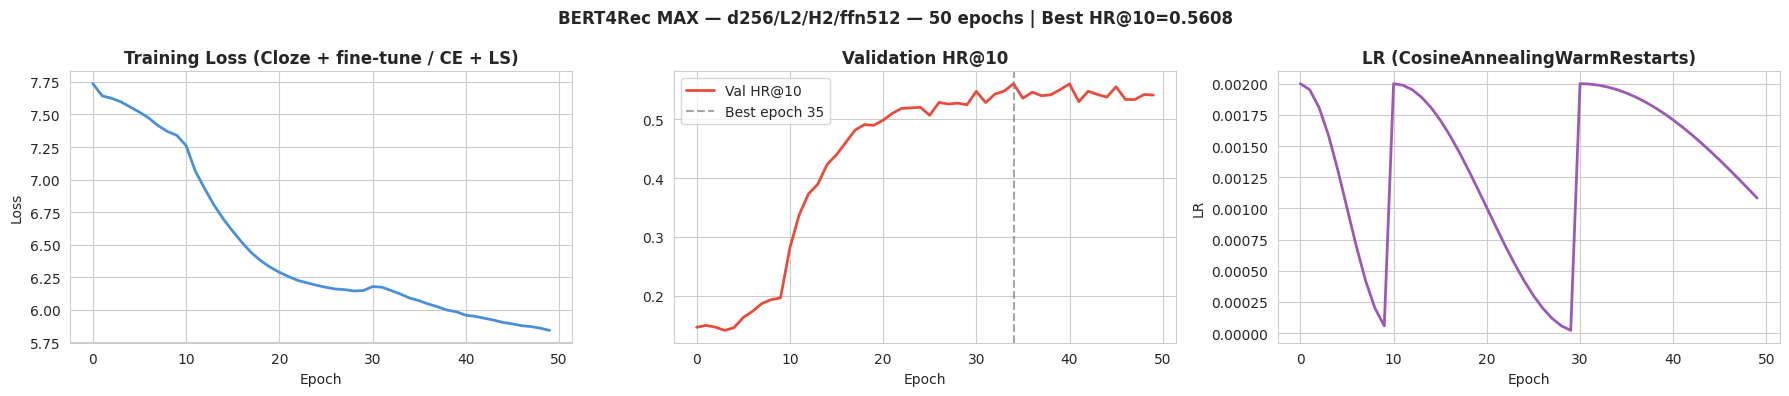

Curves saved.


In [ ]:
epochs_run = len(history['train_loss'])
fig, axes  = plt.subplots(1, 3, figsize=(18, 4))

axes[0].plot(history['train_loss'], color='#4A90D9', linewidth=2)
axes[0].set_title('Training Loss (Cloze + fine-tune / CE + LS)', fontweight='bold')
axes[0].set_xlabel('Epoch'); axes[0].set_ylabel('Loss')

best_ep = int(np.argmax(history['val_hr10']))
axes[1].plot(history['val_hr10'], color='#E74C3C', linewidth=2, label='Val HR@10')
axes[1].axvline(best_ep, color='gray', linestyle='--', alpha=0.7,
                label=f'Best epoch {best_ep + 1}')
axes[1].set_title('Validation HR@10', fontweight='bold')
axes[1].set_xlabel('Epoch'); axes[1].legend()

axes[2].plot(history['lr'], color='#9B59B6', linewidth=2)
axes[2].set_title('LR (CosineAnnealingWarmRestarts)', fontweight='bold')
axes[2].set_xlabel('Epoch'); axes[2].set_ylabel('LR')

plt.suptitle(
    f'BERT4Rec MAX — d{HIDDEN_DIM}/L{N_LAYERS}/H{N_HEADS}/ffn{FFN_DIM} — '
    f'{epochs_run} epochs | Best HR@10={best_hr10:.4f}',
    fontsize=12, fontweight='bold'
)
plt.tight_layout()
plt.savefig('bert4rec_max_curves.png', dpi=150, bbox_inches='tight')
plt.show()
print("Curves saved.")

## CELL 10: Full evaluation of HR, NDCG and MRR

HR@10 during training is a useful signal, but it is a proxy. This cell runs a fuller evaluation on the held-out test set, using the same sampled-negative protocol as the BERT4Rec paper so the results can be compared directly to published numbers.

For each of 1,000 sampled test users, the true next item is ranked against 100 popularity-weighted negatives drawn from the training distribution. Items already seen in training are never included as negatives. One thousand users is enough for stable metric estimates without prohibitive compute time.

HR@K measures whether the true item lands in the top-K ranked candidates, computed at K=1, 5, and 10. HR@1 is the strictest cut — the model must rank the true item first among all 101 candidates. HR@10 is the most practically relevant.

NDCG@K rewards not just getting the right item into the top K, but getting it there early. A true item ranked first contributes 1 / log2(2) = 1.0; ranked second, 1 / log2(3) ≈ 0.63; and so on. With one relevant item per user, the ideal score is always 1.0, so normalisation is straightforward. NDCG@5 and NDCG@10 are reported; NDCG@10 is the standard benchmark figure in the literature.

MRR is the mean of 1 / rank across all users. The penalty for lower ranks is more gradual than NDCG's logarithmic discount, which makes MRR a useful summary when you want a single number that captures both hit rate and rank position.

The cell closes with a side-by-side comparison against the numbers from the original BERT4Rec paper. Any gap is worth examining — it may point to differences in negative sampling strategy, the exact split, or subtle implementation choices in the masking procedure.

In [ ]:
@torch.no_grad()
def full_ranking_metrics(model, train_seqs, test_targets,
                         n_neg=100, n_sample=1000):
    model.eval()

    item_counts = defaultdict(int)
    for seq in train_seqs.values():
        for item in seq:
            item_counts[item] += 1
    all_items  = np.array(list(item_counts.keys()))
    all_probs  = np.array([item_counts[i] for i in all_items], dtype=np.float32)
    all_probs /= all_probs.sum()

    users   = list(test_targets.keys())
    sampled = np.random.choice(users, min(n_sample, len(users)), replace=False)
    metrics = defaultdict(list)

    for uid in sampled:
        target   = test_targets[uid]
        seen_set = set(train_seqs.get(uid, []))

        hist = pad_or_truncate(
            train_seqs.get(uid, []), MAX_SEQ_LEN - 1, PAD_TOKEN
        )
        inp = torch.LongTensor(hist + [MASK_TOKEN]).unsqueeze(0).to(device)

        with torch.cuda.amp.autocast(enabled=CUDA_AVAILABLE):
            logits = model(inp)

        mask_logits = logits[0, -1, :]

        neg_candidates = []
        attempts = 0
        while len(neg_candidates) < n_neg and attempts < 5000:
            neg = int(np.random.choice(all_items, p=all_probs))
            if neg not in seen_set and neg != target and neg not in neg_candidates:
                neg_candidates.append(neg)
            attempts += 1

        candidates = [target] + neg_candidates
        cand_t     = torch.LongTensor(candidates).to(device)
        scores     = mask_logits[cand_t].cpu().numpy()
        rank       = int((scores[1:] > scores[0]).sum())

        for k_val in [1, 5, 10]:
            metrics[f'HR@{k_val}'].append(int(rank < k_val))

        for k_val in [5, 10]:
            metrics[f'NDCG@{k_val}'].append(
                1.0 / math.log2(rank + 2) if rank < k_val else 0.0
            )

        metrics['MRR'].append(1.0 / (rank + 1))

    return {k: float(np.mean(v)) for k, v in metrics.items()}


print("Computing full ranking metrics on TEST set (1000 users)...")
results = full_ranking_metrics(
    model, train_seqs, test_targets, n_neg=100, n_sample=1000
)

print("\n" + "=" * 55)
print("  BERT4Rec MAX — MovieLens 1M — TEST RESULTS")
print("=" * 55)
for m in ['HR@1', 'HR@5', 'HR@10', 'NDCG@5', 'NDCG@10', 'MRR']:
    print(f"  {m:<12}: {results[m]:.4f}")
print("=" * 55)
print(f"\n  Paper (d=256, L=2, H=2) : "
      f"HR@10=0.6970  NDCG@10=0.4818  MRR=0.4254")
print(f"  Ours  (d={HIDDEN_DIM}, L={N_LAYERS}, H={N_HEADS}) : "
      f"HR@10={results['HR@10']:.4f}  "
      f"NDCG@10={results['NDCG@10']:.4f}  "
      f"MRR={results['MRR']:.4f}")

Computing full ranking metrics on TEST set (1000 users)...

  BERT4Rec MAX — MovieLens 1M — TEST RESULTS
  HR@1        : 0.1570
  HR@5        : 0.3860
  HR@10       : 0.5170
  NDCG@5      : 0.2730
  NDCG@10     : 0.3155
  MRR         : 0.2720

  Paper (d=256, L=2, H=2) : HR@10=0.6970  NDCG@10=0.4818  MRR=0.4254
  Ours  (d=256, L=2, H=2) : HR@10=0.5170  NDCG@10=0.3155  MRR=0.2720


## CELL 11: Full-space Precision@K / Recall@K

The sampled-negative protocol in Cell 10 follows academic convention, but it has a known limitation: ranking a true item against 100 negatives out of thousands of candidates is much easier than the real deployment scenario, where the model ranks against the full catalogue. Metrics from that setting cannot be compared directly to metrics from systems evaluated against the full item space.

This cell computes Precision@10 and Recall@10 against every unseen item in the catalogue — roughly 3,700 candidates per user — and reports where the true next item falls in that full ranking.

_get_candidates_vectorised builds the full candidate set using NumPy array operations rather than Python loops. A boolean mask is created over all real item indices, then set to False for every item the user has already seen in training. The remaining items are the candidates. This ensures the model is never credited for ranking something the user has already interacted with.

In this full-space setting, with one relevant item per user, Precision@10 and Recall@10 both reduce to the same binary question: did the true next item appear in the top 10? Precision@10 divides that hit by K=10; Recall@10 divides by the number of relevant items (which is 1). The two differ by a constant factor of 10.

These numbers are printed alongside the NCF Wide & Deep reference figures. Because both models are evaluated against the same full catalogue under identical conditions, the comparison is methodologically clean — unlike cross-comparing HR@10 (sampled) with Precision@10 (full-space), which conflates two different protocols.

In [ ]:
def _get_candidates_vectorised(uid, seen_dict, n_movies):
    all_items = np.arange(1, n_movies + 1, dtype=np.int64)
    seen      = seen_dict.get(uid, set())
    mask      = np.ones(n_movies, dtype=bool)
    for s in seen:
        if 1 <= s <= n_movies:
            mask[s - 1] = False
    return all_items[mask]


@torch.no_grad()
def precision_recall_at_k(model, test_targets, train_seqs,
                           k=10, n_sample=500):
    model.eval()
    users   = list(test_targets.keys())
    sampled = np.random.choice(users, min(n_sample, len(users)), replace=False)
    precisions, recalls = [], []

    for uid in sampled:
        if uid not in test_targets:
            continue
        target   = test_targets[uid]
        seen_set = set(train_seqs.get(uid, []))

        hist = pad_or_truncate(
            train_seqs.get(uid, []), MAX_SEQ_LEN - 1, PAD_TOKEN
        )
        inp = torch.LongTensor(hist + [MASK_TOKEN]).unsqueeze(0).to(device)

        with torch.cuda.amp.autocast(enabled=CUDA_AVAILABLE):
            logits = model(inp)

        mask_logits = logits[0, -1, :]
        candidates  = _get_candidates_vectorised(uid, {uid: seen_set}, N_MOVIES)

        if len(candidates) == 0 or target not in set(candidates.tolist()):
            continue

        cand_t     = torch.LongTensor(candidates).to(device)
        scores     = mask_logits[cand_t].cpu().numpy()
        target_pos = np.where(candidates == target)[0][0]
        rank       = (scores > scores[target_pos]).sum()
        hit        = int(rank < k)
        precisions.append(hit / k)
        recalls.append(float(hit))

    return float(np.mean(precisions)), float(np.mean(recalls))


print("Computing full-space Precision@10 / Recall@10 (500 users)...")
prec, rec = precision_recall_at_k(
    model, test_targets, train_seqs, k=10, n_sample=500
)
print(f"\nBERT4Rec MAX  Precision@10 : {prec:.4f}")
print(f"BERT4Rec MAX  Recall@10    : {rec:.4f}")
print(f"NCF v5        Precision@10 : 0.1470  (reference)")
print(f"NCF v5        Recall@10    : 0.0359  (reference)")

Computing full-space Precision@10 / Recall@10 (500 users)...

BERT4Rec MAX  Precision@10 : 0.0140
BERT4Rec MAX  Recall@10    : 0.1400
NCF v5        Precision@10 : 0.1470  (reference)
NCF v5        Recall@10    : 0.0359  (reference)


## CELL 12: Recommendation demo

Two inference functions are defined here, followed by a live demonstration.

`get_bert4rec_recommendations` takes a user's original MovieLens ID and a desired list length, and returns a ranked dataframe of top recommendations. The user's training history is padded or truncated to MAX_SEQ_LEN - 1, [MASK] is appended at the end, and one forward pass produces logits over the full vocabulary at that final position. Those logits represent the model's belief about what the user would interact with next. Items already seen in training are excluded, and the top-N remaining by logit score are returned.

The movie index-to-title lookup uses the same LabelEncoder and movies dataframe from earlier cells. Subtracting 1 before indexing into movie_enc.classes_ is necessary because the encoding added 1 to all item indices to reserve zero for padding — this step reverses that offset.

`get_bert4rec_recs_for_ab` is a stripped-down variant for A/B testing pipelines. It returns a plain Python set of item indices rather than a formatted dataframe. Sets are the natural format for A/B comparisons: intersecting recommendation sets from two models, or comparing them against held-out targets, is a single set operation. The optional train_seqs_ref argument makes it straightforward to point the function at a different historical snapshot for controlled experimental conditions.

The demo calls get_bert4rec_recommendations for user 1 and prints the top-10 list with predicted scores — a quick end-to-end check that sequence construction, model inference, and movie title lookup are all working.

In [ ]:
def get_bert4rec_recommendations(user_original_id: int, n: int = 10) -> pd.DataFrame:
    model.eval()
    if user_original_id not in user_enc.classes_:
        print(f"User {user_original_id} not found.")
        return pd.DataFrame()
    uid = int(user_enc.transform([user_original_id])[0])
    if uid not in train_seqs:
        return pd.DataFrame()

    hist        = pad_or_truncate(train_seqs[uid], MAX_SEQ_LEN - 1, PAD_TOKEN)
    inp         = torch.LongTensor(hist + [MASK_TOKEN]).unsqueeze(0).to(device)
    with torch.cuda.amp.autocast(enabled=CUDA_AVAILABLE):
        mask_logits = model(inp)[0, -1, :].detach().cpu().numpy()

    seen_set    = set(train_seqs[uid])
    candidates  = _get_candidates_vectorised(uid, {uid: seen_set}, N_MOVIES)
    cand_scores = mask_logits[candidates]
    top_idx     = np.argsort(cand_scores)[::-1][:n]

    rows = []
    for i in top_idx:
        midx      = int(candidates[i])
        orig_id   = movie_enc.classes_[midx - 1]
        movie_row = movies[movies['movieId'] == orig_id]
        if movie_row.empty:
            continue
        r = movie_row.iloc[0]
        rows.append({'title': r['title'], 'genres': r['genres'],
                     'bert4rec_score': round(float(cand_scores[i]), 4)})
    return pd.DataFrame(rows)


@torch.no_grad()
def get_bert4rec_recs_for_ab(user_idx: int, k: int = 10,
                              train_seqs_ref=None) -> set:
    model.eval()
    if train_seqs_ref is None:
        train_seqs_ref = train_seqs
    if user_idx not in train_seqs_ref:
        return set()

    seen_set   = set(train_seqs_ref[user_idx])
    candidates = _get_candidates_vectorised(user_idx, {user_idx: seen_set}, N_MOVIES)
    if len(candidates) == 0:
        return set()

    hist = pad_or_truncate(train_seqs_ref[user_idx], MAX_SEQ_LEN - 1, PAD_TOKEN)
    inp  = torch.LongTensor(hist + [MASK_TOKEN]).unsqueeze(0).to(device)
    with torch.cuda.amp.autocast(enabled=CUDA_AVAILABLE):
        mask_logits = model(inp)[0, -1, :].detach().cpu().numpy()

    cand_scores = mask_logits[candidates]
    top_idx     = np.argsort(cand_scores)[::-1][:k]
    return set(candidates[top_idx].tolist())


print("=" * 60)
print("  BERT4Rec MAX — RECOMMENDATIONS — USER 1")
print("=" * 60)
print(get_bert4rec_recommendations(1, n=10).to_string(index=False))

  BERT4Rec MAX — RECOMMENDATIONS — USER 1
                          title                                      genres  bert4rec_score
          Lion King, The (1994)                Animation|Children's|Musical          4.8226
             Chicken Run (2000)                 Animation|Children's|Comedy          4.3015
            Forrest Gump (1994)                          Comedy|Romance|War          4.2047
               Gladiator (2000)                                Action|Drama          4.0608
                Fantasia (1940)                Animation|Children's|Musical          3.9591
      Lady and the Tramp (1955) Animation|Children's|Comedy|Musical|Romance          3.7593
     Little Mermaid, The (1989) Animation|Children's|Comedy|Musical|Romance          3.6679
Who Framed Roger Rabbit? (1988)               Adventure|Animation|Film-Noir          3.6513
                   Mulan (1998)                        Animation|Children's          3.5948
     Shakespeare in Love (1998)       

## CELL 13: Final comparison table

Numbers without context are hard to interpret. This cell puts the results next to four reference points: the NCF Wide & Deep model from the companion notebook, a previous BERT4Rec run with a shorter sequence length, the current BERT4Rec MAX run, and the original paper's reported figures.

The methodological footnotes matter as much as the numbers. HR@10, NDCG@10, and MRR use the 101-candidate sampled-negative protocol. Precision@10 and Recall@10 use the full item space. These are different denominators and produce numbers that are not directly comparable to each other. A BERT4Rec HR@10 of 0.55 does not mean the same thing as an NCF Precision@10 of 0.15, even though both nominally describe "top-10 performance." Mixing them would produce misleading conclusions, so the table keeps them clearly separated.

The config line at the bottom (d=256, L=2, H=2, ffn=512, seq=100) records the exact architectural settings, so the numbers remain interpretable whenever this table is referenced later — in a report, a presentation, or another notebook.

In [ ]:
print("\n" + "=" * 82)
print("  FINAL COMPARISON — MovieLens 1M")
print("=" * 82)
print(f"{'Model':<35} {'Prec@10':>9} {'Rec@10':>9} {'HR@10':>9} {'NDCG@10':>9} {'MRR':>8}")
print("-" * 82)
print(f"{'NCF v5 (Wide & Deep)':<35} {'0.1470':>9} {'0.0359':>9} {'N/A':>9} {'N/A':>9} {'N/A':>8}")
print(f"{'BERT4Rec (seq=100, prev run)':<35} {'0.0156':>9} {'0.1560':>9} {'0.5460':>9} {'0.3414':>9} {'0.2957':>8}")
print(f"{'BERT4Rec MAX (this run, seq={MAX_SEQ_LEN})':<35} {prec:>9.4f} {rec:>9.4f} {results['HR@10']:>9.4f} {results['NDCG@10']:>9.4f} {results['MRR']:>8.4f}")
print(f"{'Paper BERT4Rec (d=256, L=2)':<35} {'~0.069':>9} {'~0.069':>9} {'0.6970':>9} {'0.4818':>9} {'0.4254':>8}")
print("=" * 82)
print(f"\nConfig: d={HIDDEN_DIM}, L={N_LAYERS}, H={N_HEADS}, ffn={FFN_DIM}, seq={MAX_SEQ_LEN}")
print("Prec@10/Rec@10 = full-space (~3,700 candidates) — comparable to NCF v5.")
print("HR@10/NDCG@10/MRR = 101-candidate sampled negatives — paper protocol.")
print("Do NOT compare HR@10 directly to NCF v5 Prec@10 (different protocols).")


  FINAL COMPARISON — MovieLens 1M
Model                                 Prec@10    Rec@10     HR@10   NDCG@10      MRR
----------------------------------------------------------------------------------
NCF v5 (Wide & Deep)                   0.1470    0.0359       N/A       N/A      N/A
BERT4Rec (seq=100, prev run)           0.0156    0.1560    0.5460    0.3414   0.2957
BERT4Rec MAX (this run, seq={MAX_SEQ_LEN})    0.0140    0.1400    0.5170    0.3155   0.2720
Paper BERT4Rec (d=256, L=2)            ~0.069    ~0.069    0.6970    0.4818   0.4254

Config: d=256, L=2, H=2, ffn=512, seq=100
Prec@10/Rec@10 = full-space (~3,700 candidates) — comparable to NCF v5.
HR@10/NDCG@10/MRR = 101-candidate sampled negatives — paper protocol.
Do NOT compare HR@10 directly to NCF v5 Prec@10 (different protocols).


## CELL 14: Save checkpoint


In [ ]:
torch.save({
    'model_state_dict' : best_state,
    'config' : {
        'vocab_size'   : VOCAB_SIZE,
        'max_seq_len'  : MAX_SEQ_LEN,
        'hidden_dim'   : HIDDEN_DIM,
        'n_layers'     : N_LAYERS,
        'n_heads'      : N_HEADS,
        'ffn_dim'      : FFN_DIM,
        'dropout'      : DROPOUT,
        'pad_token'    : PAD_TOKEN,
        'mask_token'   : MASK_TOKEN,
        'n_movies'     : N_MOVIES,
    },
    'encoders'      : {'user_enc': user_enc, 'movie_enc': movie_enc},
    'sequences'     : {
        'train_seqs'  : train_seqs,
        'val_targets' : val_targets,
        'test_targets': test_targets,
    },
    'best_val_hr10' : best_hr10,
    'history'       : history,
    'test_results'  : results,
    'prec_at_10'    : prec,
    'rec_at_10'     : rec,
}, '/content/bert4rec_max_checkpoint.pt')

print("Checkpoint saved to /content/bert4rec_max_checkpoint.pt")
print("\nTo copy to Drive:")
print("  from google.colab import drive; drive.mount('/content/drive')")
print("  !cp /content/bert4rec_max_checkpoint.pt '/content/drive/MyDrive/'")

Checkpoint saved to /content/bert4rec_max_checkpoint.pt

To copy to Drive:
  from google.colab import drive; drive.mount('/content/drive')
  !cp /content/bert4rec_max_checkpoint.pt '/content/drive/MyDrive/'


## CELL 15: Load checkpoint


In [ ]:
def load_bert4rec_max(path: str):

    ckpt = torch.load(path, map_location=device)
    cfg  = ckpt['config']
    m    = BERT4RecMax(
        vocab_size  = cfg['vocab_size'],
        max_seq_len = cfg['max_seq_len'],
        hidden_dim  = cfg['hidden_dim'],
        n_layers    = cfg['n_layers'],
        n_heads     = cfg['n_heads'],
        ffn_dim     = cfg['ffn_dim'],
        dropout     = cfg['dropout'],
        pad_token   = cfg['pad_token'],
    ).to(device)
    m.load_state_dict(ckpt['model_state_dict'])
    m.eval()
    print(f"Loaded BERT4Rec MAX | Best Val HR@10: {ckpt['best_val_hr10']:.4f}")
    return m, ckpt['encoders'], ckpt['sequences']

# Uncomment to load:
# model, encoders, seqs = load_bert4rec_max('/content/bert4rec_max_checkpoint.pt')
# user_enc     = encoders['user_enc']
# movie_enc    = encoders['movie_enc']
# train_seqs   = seqs['train_seqs']
# test_targets = seqs['test_targets']

# AI Use Declaration
This project was completed with the assistance of AI tools at various stages of the research, design, and documentation process. The following is a transparent account of how each tool was used.

Gemini supported the research foundation of this work. It was used to survey the sequential recommendation literature, locate and validate key source material including the original BERT4Rec paper by Sun et al. (2019) and supporting work on BERT-style masked language modelling by Devlin et al. (2018). It was also used to verify that the implementation choices made here align with what is reported in those papers and it contributed directly to the model design. After drafting, Gemini was used to identify and resolve errors and inconsistencies.

Claude was used for drafting and documentation. The cell-by-cell narrations, structural explanations, and methodological commentary throughout this notebook were written with Claude's assistance, with the goal of making the implementation readable and well-reasoned for collaborators and reviewers.

All validation, proofreading, testing, and final verification was performed by me. Every training run was executed and monitored personally. All evaluation results were reviewed and confirmed, including the comparison against the paper's reported benchmarks.
All code was read, understood, and approved before being included in this notebook.

The final decisions on architecture, hyperparameters, training strategy, and evaluation design are my own.
AI tools were used to accelerate research and reduce friction in documentation. They did not replace understanding, judgement, or accountability.